In [1]:
import importlib
import sys
import numpy as np
from collections import Counter
import pandas as pd
import pickle

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [2]:
# Preprocess for BPIC20 DD:
# Remove role suffix in activity names (e.g., "[Declaration SUBMITTED by EMPLOYEE]" -> "[Declaration SUBMITTED]")
# Remove exact duplicate rows

import re

event_log_location = '../../../../../../data/data/DomesticDeclarations.csv'
df_raw = pd.read_csv(event_log_location)
activity_col = "concept:name"

def _strip_by_suffix(value):
    if pd.isna(value):
        return value
    s = str(value)
    if s == "EOS":
        return s
    # If the activity is bracketed, remove " by ..." before the closing bracket
    s = re.sub(r"\s+by\s+[^\]]+(?=\])", "", s)
    # General fallback: remove " by ..." at end of string
    s = re.sub(r"\s+by\s+.*$", "", s)
    return s

df_raw[activity_col] = df_raw[activity_col].map(_strip_by_suffix)

root, ext = os.path.splitext(event_log_location)
cleaned_event_log_location = f"{root}_cleaned{ext or '.csv'}"
df_raw.to_csv(cleaned_event_log_location, index=False)

# Use the cleaned log for the rest of this notebook
print("Wrote cleaned log to:", cleaned_event_log_location)

Wrote cleaned log to: ../../../../../../data/data/DomesticDeclarations_cleaned.csv


In [3]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = cleaned_event_log_location

result_name = 'bpic20_DD_all'

# dynamic categorical attributes
cat_dynamic = ['concept:name',
               'org:resource',
               'org:role'
              ]

# static categorical attributes
cat_static = ['case:BudgetNumber',
              'case:DeclarationNumber'
             ]

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day',
               ]

# dynamic log-normal encoded numerical attributes 
num_dyn_log = []

# static numeric attributes
num_static = ['case:Amount']

min_suffix_size = 5

train_validation_size = 0.3
# 15% test size:
test_validation_size = 0.15

event_log_properties = {# case id
                        'case_name' : 'case:concept:name',
                        # activity
                        'concept_name' : 'concept:name',
                        # time values and computaitons
                        'timestamp_name' : 'time:timestamp',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # trian and test split
                        'train_validation_size' : train_validation_size,
                        'test_validation_size' :test_validation_size,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [4]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [5]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

unique_vals = (
    pd.Series(raw_data["concept:name"])
      .explode()
      .dropna()
      .unique()
      .tolist()
)

print(unique_vals)

['Declaration SUBMITTED', 'Declaration FINAL_APPROVED', 'Request Payment', 'Payment Handled', 'Declaration APPROVED', 'Declaration REJECTED', 'Declaration SAVED', 'Declaration FOR_APPROVAL']


In [6]:
# outputs for perturbations:
# train_df, val_df, test_df = pref_adopt_dataframe.get_all_datasets()
# categories = pref_adopt_dataframe.extract_feature_info()

In [7]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:BudgetNumber,case:DeclarationNumber,case:Amount
0,declaration 86795,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[37574.0],budget 86566,declaration number 86796,182.464172
1,declaration 86795,2,"[Declaration SUBMITTED, Declaration APPROVED]","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, PRE_APPROVER]","[0.0, 3801787.0]","[nan, 3801787.0]","[0.0, 2.0]","[37574.0, 37761.0]",budget 86566,declaration number 86796,182.464172
2,declaration 86795,3,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, PRE_APPROVER, SUPERVISOR]","[0.0, 3801787.0, 3880111.0]","[nan, 3801787.0, 78324.0]","[0.0, 2.0, 3.0]","[37574.0, 37761.0, 29685.0]",budget 86566,declaration number 86796,182.464172
3,declaration 86795,4,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, PRE_APPROVER, SUPERVISOR, UNDEFINED]","[0.0, 3801787.0, 3880111.0, 4851671.0]","[nan, 3801787.0, 78324.0, 971560.0]","[0.0, 2.0, 3.0, 0.0]","[37574.0, 37761.0, 29685.0, 50845.0]",budget 86566,declaration number 86796,182.464172
4,declaration 86795,5,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, PRE_APPROVER, SUPERVISOR, UNDEFINED...","[0.0, 3801787.0, 3880111.0, 4851671.0, 5468685.0]","[nan, 3801787.0, 78324.0, 971560.0, 617014.0]","[0.0, 2.0, 3.0, 0.0, 0.0]","[37574.0, 37761.0, 29685.0, 50845.0, 63059.0]",budget 86566,declaration number 86796,182.464172
...,...,...,...,...,...,...,...,...,...,...,...,...
31019,declaration 138359,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[5.0],[64214.0],budget 86566,declaration number 138360,190.404576
31020,declaration 138359,2,"[Declaration SUBMITTED, Declaration APPROVED]","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 359.0]","[nan, 359.0]","[5.0, 5.0]","[64214.0, 64573.0]",budget 86566,declaration number 138360,190.404576
31021,declaration 138359,3,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 359.0, 399938.0]","[nan, 359.0, 399579.0]","[5.0, 5.0, 3.0]","[64214.0, 64573.0, 32152.0]",budget 86566,declaration number 138360,190.404576
31022,declaration 138359,4,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 359.0, 399938.0, 829814.0]","[nan, 359.0, 399579.0, 429876.0]","[5.0, 5.0, 3.0, 1.0]","[64214.0, 64573.0, 32152.0, 30028.0]",budget 86566,declaration number 138360,190.404576


In [8]:
train_pref_df.to_csv('../../../../encoded_data_conformance_v2/BPIC20_DD/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [9]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:BudgetNumber,case:DeclarationNumber,case:Amount
0,declaration 86791,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[35390.0],budget 86566,declaration number 86792,26.851205
1,declaration 86791,2,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, SUPERVISOR]","[0.0, 5878.0]","[nan, 5878.0]","[0.0, 0.0]","[35390.0, 41268.0]",budget 86566,declaration number 86792,26.851205
2,declaration 86791,3,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED]","[0.0, 5878.0, 85494.0]","[nan, 5878.0, 79616.0]","[0.0, 0.0, 1.0]","[35390.0, 41268.0, 34484.0]",budget 86566,declaration number 86792,26.851205
3,declaration 86791,4,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, SYSTEM, SYSTEM]","[EMPLOYEE, SUPERVISOR, UNDEFINED, UNDEFINED]","[0.0, 5878.0, 85494.0, 286892.0]","[nan, 5878.0, 79616.0, 201398.0]","[0.0, 0.0, 1.0, 3.0]","[35390.0, 41268.0, 34484.0, 63082.0]",budget 86566,declaration number 86792,26.851205
4,declaration 86805,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[42047.0],budget 86566,declaration number 86806,443.585163
...,...,...,...,...,...,...,...,...,...,...,...,...
16900,declaration 138331,2,"[Declaration SUBMITTED, Declaration APPROVED]","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 907.0]","[nan, 907.0]","[4.0, 4.0]","[59270.0, 60177.0]",budget 86566,declaration number 138332,161.048342
16901,declaration 138331,3,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER]","[0.0, 907.0, 863655.0]","[nan, 907.0, 862748.0]","[4.0, 4.0, 0.0]","[59270.0, 60177.0, 58925.0]",budget 86566,declaration number 138332,161.048342
16902,declaration 138331,4,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER, SUPER...","[0.0, 907.0, 863655.0, 941264.0]","[nan, 907.0, 862748.0, 77609.0]","[4.0, 4.0, 0.0, 1.0]","[59270.0, 60177.0, 58925.0, 50134.0]",budget 86566,declaration number 138332,161.048342
16903,declaration 138331,5,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, ADMINISTRATION, BUDGET OWNER, SUPER...","[0.0, 907.0, 863655.0, 941264.0, 1007441.0]","[nan, 907.0, 862748.0, 77609.0, 66177.0]","[4.0, 4.0, 0.0, 1.0, 2.0]","[59270.0, 60177.0, 58925.0, 50134.0, 29911.0]",budget 86566,declaration number 138332,161.048342


In [10]:
val_pref_df.to_csv('../../../../encoded_data_conformance_v2/BPIC20_DD/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [11]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,case:concept:name,prefix_length,concept:name,org:resource,org:role,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:BudgetNumber,case:DeclarationNumber,case:Amount
0,declaration 86809,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[0.0],[44076.0],budget 86566,declaration number 86810,333.440910
1,declaration 86809,2,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, SUPERVISOR]","[0.0, 13.0]","[nan, 13.0]","[0.0, 0.0]","[44076.0, 44089.0]",budget 86566,declaration number 86810,333.440910
2,declaration 86809,3,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, SUPERVISOR, MISSING]","[0.0, 13.0, 98443.0]","[nan, 13.0, 98430.0]","[0.0, 0.0, 1.0]","[44076.0, 44089.0, 56119.0]",budget 86566,declaration number 86810,333.440910
3,declaration 86809,4,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, SUPERVISOR, MISSING, EMPLOYEE]","[0.0, 13.0, 98443.0, 959331.0]","[nan, 13.0, 98430.0, 860888.0]","[0.0, 0.0, 1.0, 4.0]","[44076.0, 44089.0, 56119.0, 53007.0]",budget 86566,declaration number 86810,333.440910
4,declaration 86809,5,"[Declaration SUBMITTED, Declaration FINAL_APPR...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, STA...","[EMPLOYEE, SUPERVISOR, MISSING, EMPLOYEE, SUPE...","[0.0, 13.0, 98443.0, 959331.0, 959407.0]","[nan, 13.0, 98430.0, 860888.0, 76.0]","[0.0, 0.0, 1.0, 4.0, 4.0]","[44076.0, 44089.0, 56119.0, 53007.0, 53083.0]",budget 86566,declaration number 86810,333.440910
...,...,...,...,...,...,...,...,...,...,...,...,...
8503,declaration 138349,1,[Declaration SUBMITTED],[STAFF MEMBER],[EMPLOYEE],[0.0],[nan],[4.0],[69501.0],budget 86566,declaration number 138350,446.667698
8504,declaration 138349,2,"[Declaration SUBMITTED, Declaration APPROVED]","[STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION]","[0.0, 1012.0]","[nan, 1012.0]","[4.0, 4.0]","[69501.0, 70513.0]",budget 86566,declaration number 138350,446.667698
8505,declaration 138349,3,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER]","[EMPLOYEE, ADMINISTRATION, SUPERVISOR]","[0.0, 1012.0, 931490.0]","[nan, 1012.0, 930478.0]","[4.0, 4.0, 1.0]","[69501.0, 70513.0, 50591.0]",budget 86566,declaration number 138350,446.667698
8506,declaration 138349,4,"[Declaration SUBMITTED, Declaration APPROVED, ...","[STAFF MEMBER, STAFF MEMBER, STAFF MEMBER, SYS...","[EMPLOYEE, ADMINISTRATION, SUPERVISOR, UNDEFINED]","[0.0, 1012.0, 931490.0, 997140.0]","[nan, 1012.0, 930478.0, 65650.0]","[4.0, 4.0, 1.0, 2.0]","[69501.0, 70513.0, 50591.0, 29841.0]",budget 86566,declaration number 138350,446.667698


In [12]:
test_pref_df.to_csv('../../../../encoded_data_conformance_v2/BPIC20_DD/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

In [13]:
# Optional set list of ids the petri net should be executed:
unique_list_train = train_pref_df["case:concept:name"].dropna().unique().tolist()
unique_list_val = val_pref_df["case:concept:name"].dropna().unique().tolist()

case_ids = list(dict.fromkeys(unique_list_train + unique_list_val))

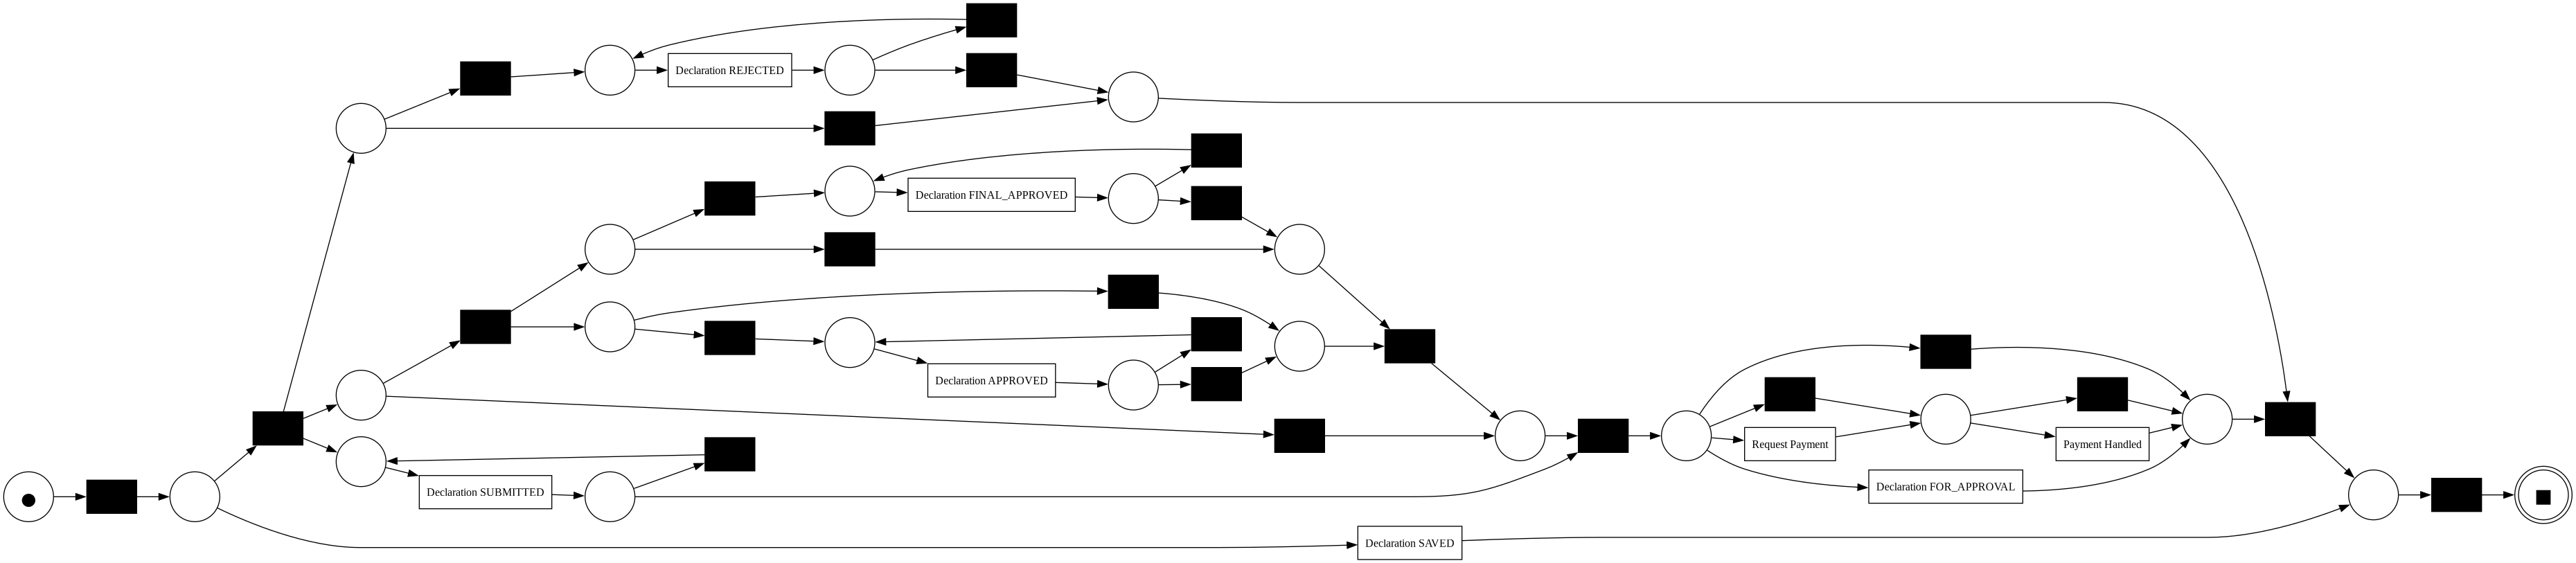

In [14]:
# Calculate and store markings:
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="case:concept:name", activity_col="concept:name", timestamp_col="time:timestamp", resource_col="org:resource")
store_loc_file_path ='../../../../encoded_data_conformance_v2/BPIC20_DD/prefix_for_replay/petri_net/bpic20_DD.png'
net, im, fm = miner.discover_petri_net(visulaize=True,
                                       case_ids=case_ids,
                                       store_loc_file_path=store_loc_file_path)

# store discovered petri net objects next to the PNG
pkl_path = os.path.splitext(store_loc_file_path)[0] + '.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump((net, im, fm), f)

In [15]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="concept:name")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  31024


,marking,count
0,"[p_5, p_16, p_20, p_28]",5812
1,"[p_5, p_18, p_16]",5694
2,"[p_5, p_11]",4979
3,"[p_5, p_30]",4975
4,"[p_5, p_16, p_28, p_23]",4237
5,"[p_18, p_16, p_8]",1163
6,"[p_5, p_16, p_25, p_23]",781
7,"[p_8, p_30]",533
8,"[p_8, p_11]",533
9,"[p_8, p_16, p_28, p_23]",500


In [16]:
# validation set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="concept:name")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  16905


,marking,count
0,"[p_5, p_18, p_16]",3110
1,"[p_5, p_16, p_20, p_28]",3089
2,"[p_5, p_11]",2722
3,"[p_5, p_30]",2719
4,"[p_5, p_16, p_28, p_23]",2302
5,"[p_18, p_16, p_8]",636
6,"[p_5, p_16, p_25, p_23]",448
7,"[p_8, p_30]",298
8,"[p_8, p_11]",298
9,"[p_8, p_16, p_20, p_28]",278


In [17]:
# test set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="concept:name")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  8508


,marking,count
0,"[p_5, p_18, p_16]",1561
1,"[p_5, p_16, p_20, p_28]",1538
2,"[p_5, p_30]",1367
3,"[p_5, p_11]",1365
4,"[p_5, p_16, p_28, p_23]",1144
5,"[p_18, p_16, p_8]",341
6,"[p_5, p_16, p_25, p_23]",233
7,"[p_8, p_16, p_20, p_28]",155
8,"[p_8, p_11]",149
9,"[p_8, p_30]",146


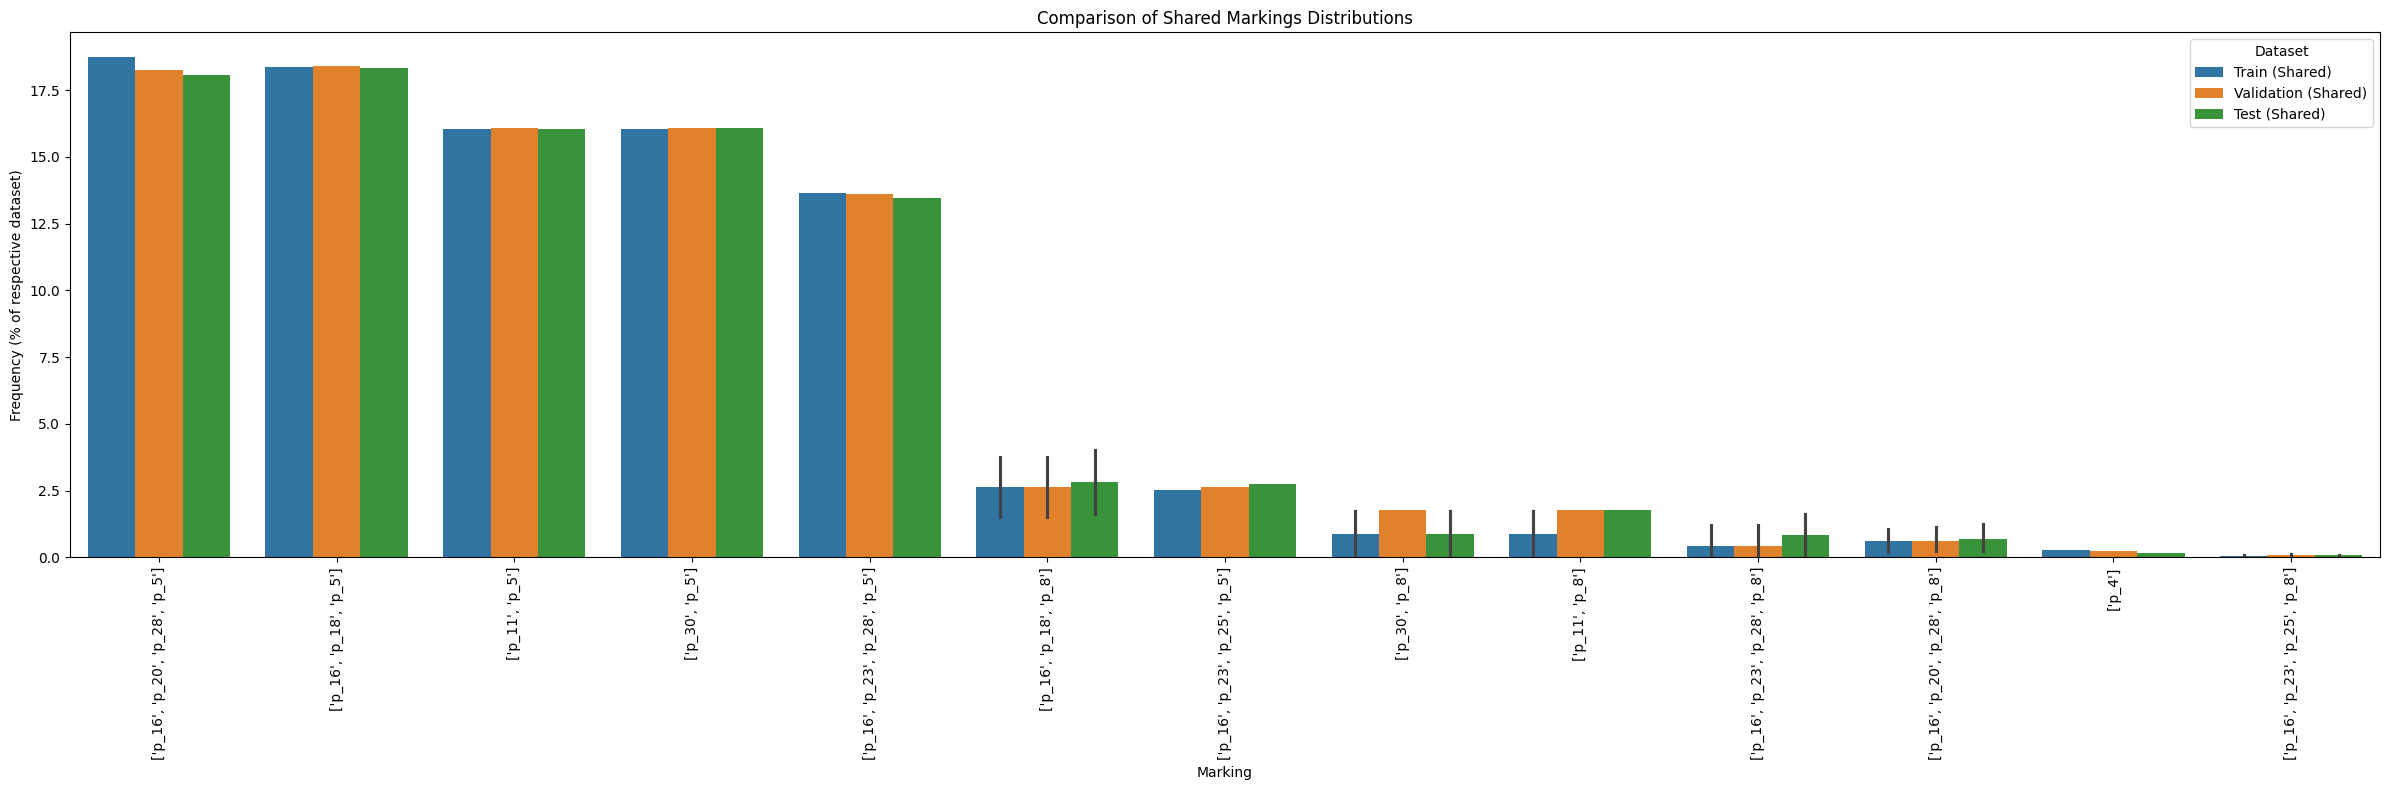

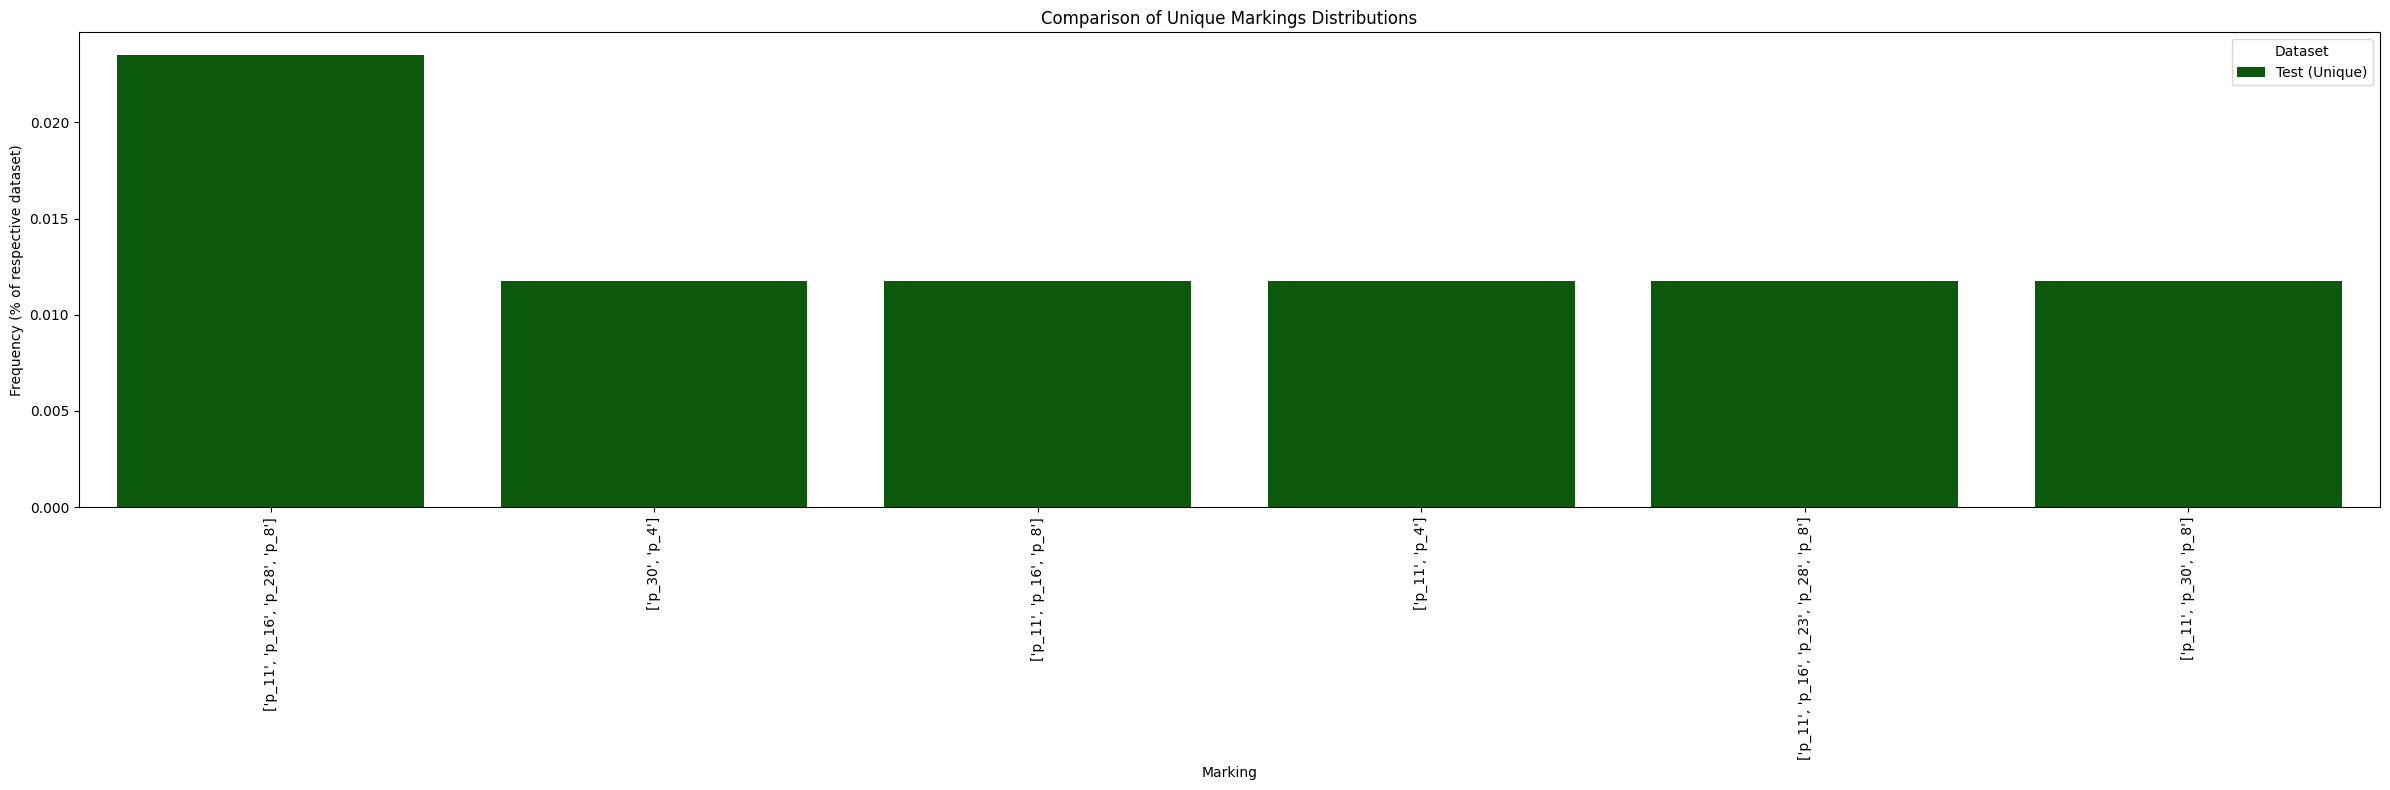

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Process train markings
markings_summary_train['marking_str'] = markings_summary_train['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_train['freq'] = (markings_summary_train['count'] / markings_summary_train['count'].sum()) * 100
markings_summary_train['dataset'] = 'Train'

# Process validation markings
markings_summary_val['marking_str'] = markings_summary_val['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_val['freq'] = (markings_summary_val['count'] / markings_summary_val['count'].sum()) * 100
markings_summary_val['dataset'] = 'Validation'

# Process test markings
markings_summary_test['marking_str'] = markings_summary_test['marking'].apply(lambda x: str(sorted([str(i) for i in x])))
markings_summary_test['freq'] = (markings_summary_test['count'] / markings_summary_test['count'].sum()) * 100
markings_summary_test['dataset'] = 'Test'

# Combine
combined_markings = pd.concat([
    markings_summary_train[['marking_str', 'freq', 'dataset']],
    markings_summary_val[['marking_str', 'freq', 'dataset']], 
    markings_summary_test[['marking_str', 'freq', 'dataset']]
])

# Identify unique markings
train_markings = set(markings_summary_train['marking_str'])
val_markings = set(markings_summary_val['marking_str'])
test_markings = set(markings_summary_test['marking_str'])

def get_category(row):
    m = row['marking_str']
    d = row['dataset']
    unique = False
    if d == 'Train' and m not in val_markings and m not in test_markings:
        unique = True
    elif d == 'Validation' and m not in train_markings and m not in test_markings:
        unique = True
    elif d == 'Test' and m not in train_markings and m not in val_markings:
        unique = True
    
    return f"{d} ({'Unique' if unique else 'Shared'})"

combined_markings['category'] = combined_markings.apply(get_category, axis=1)

# Split into Shared and Unique datasets
shared_data = combined_markings[combined_markings['category'].str.contains('Shared')]
unique_data = combined_markings[combined_markings['category'].str.contains('Unique')]

# Plot 1: Shared Markings
plt.figure(figsize=(24, 8))
palette_shared = {
    'Train (Shared)': 'tab:blue',
    'Validation (Shared)': 'tab:orange', 
    'Test (Shared)': 'tab:green'
}
sns.barplot(data=shared_data, x='marking_str', y='freq', hue='category', palette=palette_shared)
plt.xticks(rotation=90)
plt.title('Comparison of Shared Markings Distributions')
plt.ylabel('Frequency (% of respective dataset)')
plt.xlabel('Marking')
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Unique Markings
plt.figure(figsize=(24, 8))
palette_unique = {
    'Train (Unique)': 'darkblue',
    'Validation (Unique)': 'darkorange',
    'Test (Unique)': 'darkgreen'
}

if not unique_data.empty:
    sns.barplot(data=unique_data, x='marking_str', y='freq', hue='category', palette=palette_unique)
    plt.xticks(rotation=90)
    plt.title('Comparison of Unique Markings Distributions')
    plt.ylabel('Frequency (% of respective dataset)')
    plt.xlabel('Marking')
    plt.legend(title='Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("No unique markings found across datasets.")

In [19]:
# Remove prefixes whose Petri net marking is unique to one split (Train/Val/Test)
"""
print("All prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))

(train_pref_df,
 val_pref_df,
 test_pref_df,
 markings_train,
 markings_val,
 markings_test,
 (keep_train_ix, keep_val_ix, keep_test_ix))= pref_adopt_dataframe.remove_prefixes_with_unique_markings(train_pref_df,
                                                                                                        val_pref_df,
                                                                                                        test_pref_df,
                                                                                                        markings_train,
                                                                                                        markings_val,
                                                                                                        markings_test)


print("Kept prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))
"""

'\nprint("All prefixes (train/val/test):", len(train_pref_df), len(val_pref_df), len(test_pref_df))\n\n(train_pref_df,\n val_pref_df,\n test_pref_df,\n markings_train,\n markings_val,\n markings_test,\n (keep_train_ix, keep_val_ix, keep_test_ix))= pref_adopt_dataframe.remove_prefixes_with_unique_markings(train_pref_df,\n                                                                                                        val_pref_df,\n                                                                                                        test_pref_df,\n                                                                                                        markings_train,\n                                                                                                        markings_val,\n                                                                                                        markings_test)\n\n\nprint("Kept prefixes (train/val/test):", len(train_pref_df), len(val_pref_df)

## Dtore datasets and credentials for Deep-NN

In [20]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [21]:
# test
test_set = el_loader.get_encoded_dataframe(type='test')
test_set

,case:concept:name,id,org:resource,concept:name,time:timestamp,org:role,case:id,case:BudgetNumber,case:DeclarationNumber,case:Amount,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,declaration 86809,st_step 86814_0,STAFF MEMBER,Declaration SUBMITTED,2017-01-09 12:14:36,EMPLOYEE,declaration 86809,budget 86566,declaration number 86810,333.44091,0.0,NaN,0.0,44076.0
1,declaration 86809,st_step 86813_0,STAFF MEMBER,Declaration FINAL_APPROVED,2017-01-09 12:14:49,SUPERVISOR,declaration 86809,budget 86566,declaration number 86810,333.44091,13.0,13.0,0.0,44089.0
2,declaration 86809,st_step 86815_0,STAFF MEMBER,Declaration REJECTED,2017-01-10 15:35:19,MISSING,declaration 86809,budget 86566,declaration number 86810,333.44091,98443.0,98430.0,1.0,56119.0
3,declaration 86809,st_step 86812_0,STAFF MEMBER,Declaration SUBMITTED,2017-01-20 14:43:27,EMPLOYEE,declaration 86809,budget 86566,declaration number 86810,333.44091,959331.0,860888.0,4.0,53007.0
4,declaration 86809,st_step 86811_0,STAFF MEMBER,Declaration FINAL_APPROVED,2017-01-20 14:44:43,SUPERVISOR,declaration 86809,budget 86566,declaration number 86810,333.44091,959407.0,76.0,4.0,53083.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16378,declaration 138349,NaN,EOS,EOS,NaT,EOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16379,declaration 138349,NaN,EOS,EOS,NaT,EOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16380,declaration 138349,NaN,EOS,EOS,NaT,EOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16381,declaration 138349,NaN,EOS,EOS,NaT,EOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data_conformance_v2/BPIC20_DD/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/5775 [00:00<?, ?it/s]

org:resource:   0%|          | 0/5775 [00:00<?, ?it/s]

org:role:   0%|          | 0/5775 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/5775 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/5775 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/5775 [00:00<?, ?it/s]

static categorical:   0%|          | 0/31024 [00:00<?, ?it/s]

static continuous:   0%|          | 0/31024 [00:00<?, ?it/s]

In [23]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 10, {'Declaration APPROVED': 1, 'Declaration FINAL_APPROVED': 2, 'Declaration FOR_APPROVAL': 3, 'Declaration REJECTED': 4, 'Declaration SAVED': 5, 'Declaration SUBMITTED': 6, 'EOS': 7, 'Payment Handled': 8, 'Request Payment': 9}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('case:BudgetNumber', 2, {'budget 86566': 1}), ('case:DeclarationNumber', 5515, {'UNKNOWN': 1, 'declaration number 100001': 2, 'declaration number 100011': 3, 'declaration number 100016': 4, 'declaration number 100038': 5, 'declaration numbe

In [24]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data_conformance_v2/BPIC20_DD/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/3150 [00:00<?, ?it/s]

org:resource:   0%|          | 0/3150 [00:00<?, ?it/s]

org:role:   0%|          | 0/3150 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/3150 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/3150 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/3150 [00:00<?, ?it/s]

static categorical:   0%|          | 0/16905 [00:00<?, ?it/s]

static continuous:   0%|          | 0/16905 [00:00<?, ?it/s]

In [25]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 10, {'Declaration APPROVED': 1, 'Declaration FINAL_APPROVED': 2, 'Declaration FOR_APPROVAL': 3, 'Declaration REJECTED': 4, 'Declaration SAVED': 5, 'Declaration SUBMITTED': 6, 'EOS': 7, 'Payment Handled': 8, 'Request Payment': 9}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('case:BudgetNumber', 2, {'budget 86566': 1}), ('case:DeclarationNumber', 5515, {'UNKNOWN': 1, 'declaration number 100001': 2, 'declaration number 100011': 3, 'declaration number 100016': 4, 'declaration number 100038': 5, 'declaration numbe

In [26]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data_conformance_v2/BPIC20_DD/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/1575 [00:00<?, ?it/s]

org:resource:   0%|          | 0/1575 [00:00<?, ?it/s]

org:role:   0%|          | 0/1575 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/1575 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/1575 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/1575 [00:00<?, ?it/s]

static categorical:   0%|          | 0/8508 [00:00<?, ?it/s]

static continuous:   0%|          | 0/8508 [00:00<?, ?it/s]

In [27]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 10, {'Declaration APPROVED': 1, 'Declaration FINAL_APPROVED': 2, 'Declaration FOR_APPROVAL': 3, 'Declaration REJECTED': 4, 'Declaration SAVED': 5, 'Declaration SUBMITTED': 6, 'EOS': 7, 'Payment Handled': 8, 'Request Payment': 9}), ('org:resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('org:role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {})])
Categories and encoding params for static categorical and continuous values:  ([('case:BudgetNumber', 2, {'budget 86566': 1}), ('case:DeclarationNumber', 5515, {'UNKNOWN': 1, 'declaration number 100001': 2, 'declaration number 100011': 3, 'declaration number 100016': 4, 'declaration number 100038': 5, 'declaration numbe